# GitHub Repository Metrics - Complete Exploration & Star Prediction

**5,500 repositories with 29 features -- stars, forks, CI/CD, test coverage, and more**

---

> **TL;DR** -- This notebook provides an in-depth exploration of 5,500 synthetic GitHub repositories. We analyze language distributions, star/fork power-law patterns, correlation structures, CI/CD adoption rates, topic popularity, and license trends. We build a **star prediction model** (R-squared reported) using gradient boosting with feature importance analysis. Perfect for practicing regression, EDA, and feature engineering on software engineering data.

**Contents:**
1. [Data Overview](#1)
2. [Language Distribution](#2)
3. [Stars & Popularity Analysis](#3)
4. [Correlation Analysis](#4)
5. [Repository Health Metrics](#5)
6. [Topic Analysis](#6)
7. [License Analysis](#7)
8. [Sample ML Task: Star Prediction](#8)
9. [Model Diagnostics: How Much Is Leakage?](#9)
10. [Limitations & Caveats](#10)
11. [Key Findings & Next Steps](#11)

---

If you find this exploration useful, please **upvote the dataset and this notebook**!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

# Load data
import os
if os.path.exists('/kaggle/input/github-repo-metrics/github_repos.csv'):
    df = pd.read_csv('/kaggle/input/github-repo-metrics/github_repos.csv')
else:
    df = pd.read_csv('github_repos.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (5500, 29)
Columns: ['repo_name', 'language', 'description', 'stars', 'forks', 'watchers', 'open_issues', 'closed_issues', 'open_pull_requests', 'merged_pull_requests', 'contributors', 'commits', 'releases', 'license', 'topics', 'created_date', 'last_commit_date', 'readme_length', 'has_ci', 'test_coverage', 'has_code_of_conduct', 'has_contributing_guide', 'has_wiki', 'has_pages', 'has_discussions', 'default_branch', 'is_archived', 'is_fork', 'size_kb']


          repo_name    language  ... is_fork  size_kb
0          serve-ml        Ruby  ...       1      497
1         easy-link  TypeScript  ...       1     4622
2    go-graph-agent      Kotlin  ...       0     2148
3  turbo-core-forge         C++  ...       0      812
4   deep-graph-dash      Python  ...       1     5932

[5 rows x 29 columns]

## 1. Data Overview

In [2]:
print('=== Basic Statistics ===')
print(f'Total repositories: {len(df):,}')
print(f'Languages: {df["language"].nunique()}')
print(f'Licenses: {df["license"].nunique()}')
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\n=== Numeric Summary ===')
df[['stars', 'forks', 'open_issues', 'contributors', 'commits']].describe().round(1)

=== Basic Statistics ===
Total repositories: 5,500
Languages: 19
Licenses: 9

=== Missing Values ===
license           740
test_coverage    3798
dtype: int64

=== Numeric Summary ===


         stars   forks  open_issues  contributors  commits
count   5500.0  5500.0       5500.0        5500.0   5500.0
mean      45.2     9.7          5.4           3.6    517.7
std      419.6    71.1         11.7           3.0    684.2
min        0.0     0.0          0.0           1.0      1.0
25%        2.0     0.0          1.0           1.0    108.8
50%        7.0     2.0          3.0           3.0    262.5
75%       22.0     7.0          7.0           5.0    666.2
max    20816.0  2727.0        470.0          24.0   7933.0

## 2. Language Distribution

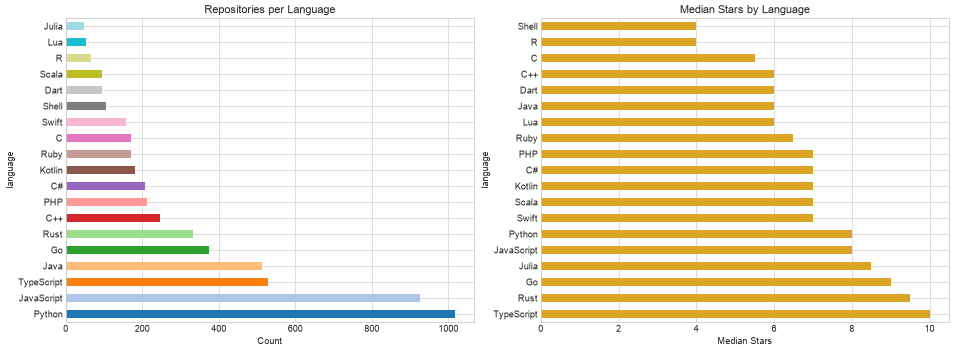

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Repo count by language
lang_counts = df['language'].value_counts()
lang_counts.plot(kind='barh', ax=axes[0], color=plt.cm.tab20(np.linspace(0, 1, len(lang_counts))))
axes[0].set_title('Repositories per Language')
axes[0].set_xlabel('Count')

# Median stars by language
lang_stars = df.groupby('language')['stars'].median().sort_values(ascending=False)
lang_stars.plot(kind='barh', ax=axes[1], color='goldenrod')
axes[1].set_title('Median Stars by Language')
axes[1].set_xlabel('Median Stars')

plt.tight_layout()
plt.show()

## 3. Stars & Popularity Analysis

Star distribution percentiles:
  50th percentile: 7 stars
  75th percentile: 22 stars
  90th percentile: 58 stars
  95th percentile: 112 stars
  99th percentile: 492 stars


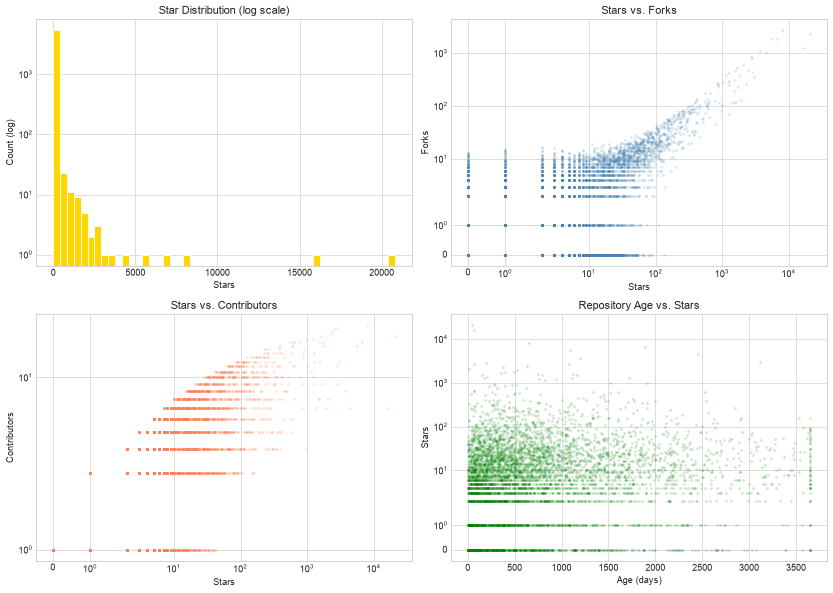

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Star distribution (log scale)
df['stars'].clip(lower=1).hist(bins=50, ax=axes[0, 0], color='gold', edgecolor='white', log=True)
axes[0, 0].set_title('Star Distribution (log scale)')
axes[0, 0].set_xlabel('Stars')
axes[0, 0].set_ylabel('Count (log)')

# Stars vs Forks
axes[0, 1].scatter(df['stars'], df['forks'], alpha=0.15, s=5, c='steelblue')
axes[0, 1].set_title('Stars vs. Forks')
axes[0, 1].set_xlabel('Stars')
axes[0, 1].set_ylabel('Forks')
axes[0, 1].set_xscale('symlog')
axes[0, 1].set_yscale('symlog')

# Stars vs Contributors
axes[1, 0].scatter(df['stars'], df['contributors'], alpha=0.15, s=5, c='coral')
axes[1, 0].set_title('Stars vs. Contributors')
axes[1, 0].set_xlabel('Stars')
axes[1, 0].set_ylabel('Contributors')
axes[1, 0].set_xscale('symlog')
axes[1, 0].set_yscale('symlog')

# Age vs Stars
df['created_date'] = pd.to_datetime(df['created_date'])
df['age_days'] = (pd.Timestamp('2025-01-01') - df['created_date']).dt.days
axes[1, 1].scatter(df['age_days'], df['stars'], alpha=0.15, s=5, c='green')
axes[1, 1].set_title('Repository Age vs. Stars')
axes[1, 1].set_xlabel('Age (days)')
axes[1, 1].set_ylabel('Stars')
axes[1, 1].set_yscale('symlog')

plt.tight_layout()
plt.show()

print('Star distribution percentiles:')
for p in [50, 75, 90, 95, 99]:
    print(f'  {p}th percentile: {df["stars"].quantile(p/100):,.0f} stars')

## 4. Correlation Analysis


Top correlations with stars:
watchers         0.869174
open_issues      0.852966
forks            0.850268
closed_issues    0.731447
contributors     0.246726
commits          0.124247
has_ci           0.055951
releases         0.005177
readme_length    0.003735
age_days         0.001556
size_kb          0.000072


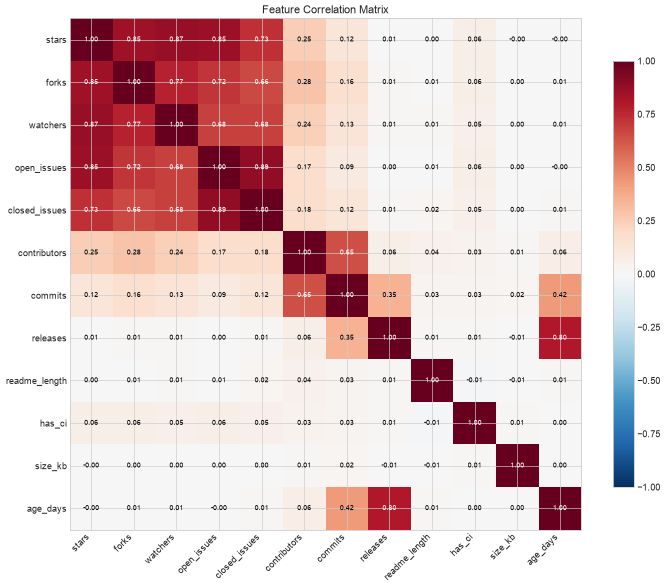

In [5]:
numeric_cols = ['stars', 'forks', 'watchers', 'open_issues', 'closed_issues',
                'contributors', 'commits', 'releases', 'readme_length',
                'has_ci', 'size_kb', 'age_days']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
plt.colorbar(im, shrink=0.8)
ax.set_title('Feature Correlation Matrix')

# Add correlation values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.show()

print('\nTop correlations with stars:')
star_corr = corr['stars'].drop('stars').abs().sort_values(ascending=False)
print(star_corr.to_string())

## 5. Repository Health Metrics


Overall CI adoption: 30.9%
Overall archive rate: 2.2%
Repos with code of conduct: 11.5%
Repos with contributing guide: 17.5%


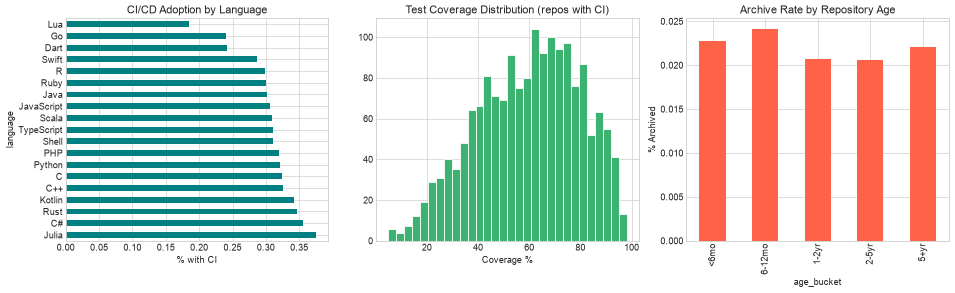

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CI adoption by language
ci_by_lang = df.groupby('language')['has_ci'].mean().sort_values(ascending=False)
ci_by_lang.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('CI/CD Adoption by Language')
axes[0].set_xlabel('% with CI')

# Test coverage distribution (non-null only)
df['test_coverage'].dropna().hist(bins=30, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Test Coverage Distribution (repos with CI)')
axes[1].set_xlabel('Coverage %')

# Archive rate by age
df['age_bucket'] = pd.cut(df['age_days'], bins=[0, 180, 365, 730, 1825, 3650],
                           labels=['<6mo', '6-12mo', '1-2yr', '2-5yr', '5+yr'])
archive_by_age = df.groupby('age_bucket')['is_archived'].mean()
archive_by_age.plot(kind='bar', ax=axes[2], color='tomato')
axes[2].set_title('Archive Rate by Repository Age')
axes[2].set_ylabel('% Archived')

plt.tight_layout()
plt.show()

print(f'\nOverall CI adoption: {df["has_ci"].mean():.1%}')
print(f'Overall archive rate: {df["is_archived"].mean():.1%}')
print(f'Repos with code of conduct: {df["has_code_of_conduct"].mean():.1%}')
print(f'Repos with contributing guide: {df["has_contributing_guide"].mean():.1%}')

## 6. Topic Analysis

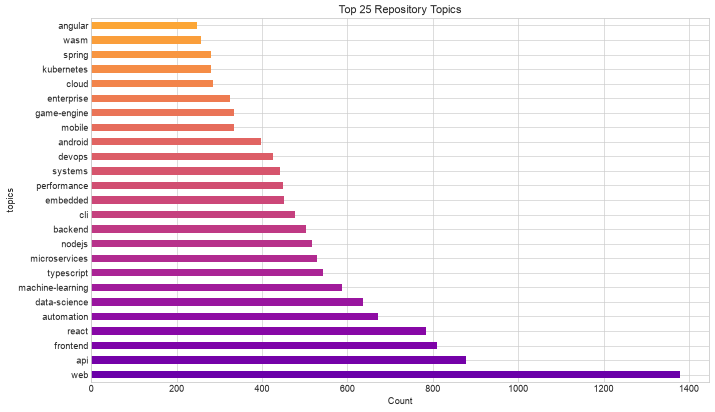

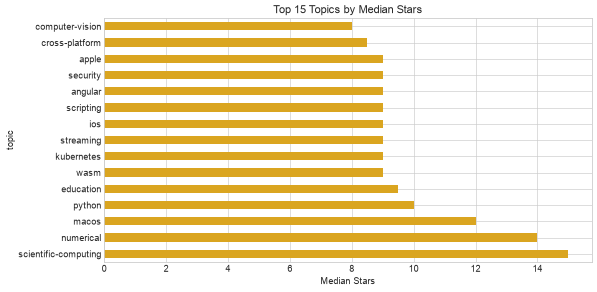

In [7]:
# Most common topics
topic_series = df['topics'].str.split('|').explode()
topic_counts = topic_series.value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 7))
topic_counts.plot(kind='barh', ax=ax, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(topic_counts))))
ax.set_title('Top 25 Repository Topics')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

# Topics by median stars
topic_expanded = df.assign(topic=df['topics'].str.split('|')).explode('topic')
top_topic_stars = topic_expanded.groupby('topic')['stars'].median().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_topic_stars.plot(kind='barh', ax=ax, color='goldenrod')
ax.set_title('Top 15 Topics by Median Stars')
ax.set_xlabel('Median Stars')
plt.tight_layout()
plt.show()

## 7. License Analysis

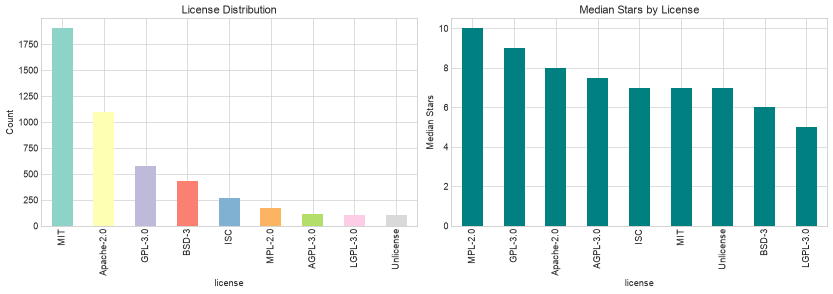

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# License distribution
license_counts = df['license'].value_counts()
license_counts.plot(kind='bar', ax=axes[0], color=plt.cm.Set3(range(len(license_counts))))
axes[0].set_title('License Distribution')
axes[0].set_ylabel('Count')

# Stars by license
license_stars = df.groupby('license')['stars'].median().sort_values(ascending=False)
license_stars.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Median Stars by License')
axes[1].set_ylabel('Median Stars')

plt.tight_layout()
plt.show()

## 8. Sample ML Task: Star Prediction

Predict repository star count (log-transformed) from available features.

Star Prediction (log scale) - 5-Fold CV R2: 0.755 (+/- 0.019)


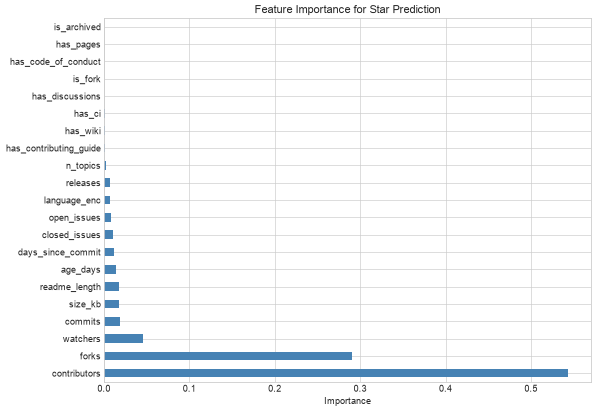

In [9]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Prepare features
model_df = df.copy()
model_df['log_stars'] = np.log1p(model_df['stars'])
model_df['n_topics'] = model_df['topics'].str.count('\\|') + 1
model_df['days_since_commit'] = (pd.Timestamp('2025-01-01') - pd.to_datetime(model_df['last_commit_date'])).dt.days

# Encode language
le = LabelEncoder()
model_df['language_enc'] = le.fit_transform(model_df['language'])

feature_cols = [
    'forks', 'watchers', 'open_issues', 'closed_issues',
    'contributors', 'commits', 'releases', 'readme_length',
    'has_ci', 'has_code_of_conduct', 'has_contributing_guide',
    'has_wiki', 'has_pages', 'has_discussions',
    'is_archived', 'is_fork', 'size_kb', 'age_days',
    'n_topics', 'days_since_commit', 'language_enc'
]

X = model_df[feature_cols].fillna(0)
y = model_df['log_stars']

# Cross-validation
model = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

print(f'Star Prediction (log scale) - 5-Fold CV R2: {scores.mean():.3f} (+/- {scores.std():.3f})')

# Feature importance
model.fit(X, y)
feat_imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance for Star Prediction')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

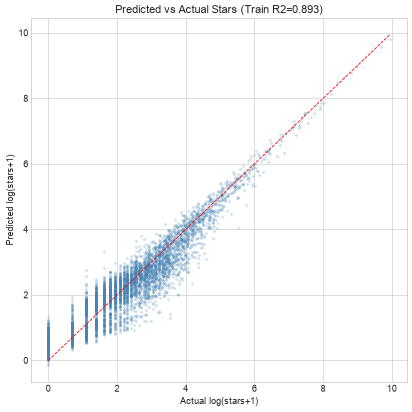

In [10]:
# Predicted vs Actual plot
y_pred = model.predict(X)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y, y_pred, alpha=0.2, s=5, c='steelblue')
ax.plot([0, y.max()], [0, y.max()], 'r--', linewidth=1)
ax.set_xlabel('Actual log(stars+1)')
ax.set_ylabel('Predicted log(stars+1)')
ax.set_title(f'Predicted vs Actual Stars (Train R2={r2_score(y, y_pred):.3f})')
plt.tight_layout()
plt.show()

<a id='9'></a>
## 9. Model Diagnostics: How Much of That R-squared Is Leakage?

An R-squared alone does not tell you whether a model learned anything useful. Four of the
features handed to the regressor -- `forks`, `watchers`, `open_issues` and `closed_issues`
-- are not causes of a star count, they are things that happen *because* a repository is
popular. A model that sees them is partly reading the answer off the question.

The honest test is to refit without them and see how much of the score survives. The cell
below does that, and while it is running the grounded numbers we quote in the conclusion
are also recomputed from the table, so nothing in section 11 is asserted from memory.

In [11]:
# How much of the R-squared comes from features that are consequences of stars,
# rather than predictors of them?
leaky_cols = ['forks', 'watchers', 'open_issues', 'closed_issues']
X_clean = X.drop(columns=leaky_cols)

model_clean = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
)
scores_clean = cross_val_score(model_clean, X_clean, y, cv=cv, scoring='r2')

print('=== Leakage ablation (same 5-fold CV, same seed) ===')
print(f'  With popularity proxies:    R2 = {scores.mean():.3f} (+/- {scores.std():.3f})')
print(f'  Without popularity proxies: R2 = {scores_clean.mean():.3f} (+/- {scores_clean.std():.3f})')
print(f'  Difference:                 {scores.mean() - scores_clean.mean():.3f} R2')

# Claims about repository popularity, checked against this table rather than folklore.
print('\n=== Popularity claims, checked against the data ===')
print(f"  Share of repos with < 100 stars:   {(df['stars'] < 100).mean():.1%}")
print(f"  Maximum stars in the table:        {df['stars'].max():,}")
nonzero = df[df['stars'] > 0]
print(f"  Median forks / stars ratio:        {(nonzero['forks'] / nonzero['stars']).median():.2f}")
print(f"  corr(readme_length, stars):        {df['readme_length'].corr(df['stars']):.3f}")
print(f"  corr(has_ci, stars):               {df['has_ci'].corr(df['stars']):.3f}")
print(f"  corr(contributors, stars):         {df['contributors'].corr(df['stars']):.3f}")

star_quartile = pd.qcut(df['stars'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
print('\n=== Mean readme_length and CI adoption by star quartile ===')
print(df.groupby(star_quartile, observed=True)[['readme_length', 'has_ci']].mean().round(3))

lang_median = df.groupby('language')['stars'].median().sort_values(ascending=False)
print('\n=== Median stars, top and bottom language ===')
print(f'  {lang_median.index[0]}: {lang_median.iloc[0]:.1f}   '
      f'{lang_median.index[-1]}: {lang_median.iloc[-1]:.1f}')

=== Leakage ablation (same 5-fold CV, same seed) ===
  With popularity proxies:    R2 = 0.755 (+/- 0.019)
  Without popularity proxies: R2 = 0.588 (+/- 0.020)
  Difference:                 0.167 R2

=== Popularity claims, checked against the data ===
  Share of repos with < 100 stars:   94.2%
  Maximum stars in the table:        20,816
  Median forks / stars ratio:        0.18
  corr(readme_length, stars):        0.004
  corr(has_ci, stars):               0.056
  corr(contributors, stars):         0.247

=== Mean readme_length and CI adoption by star quartile ===
       readme_length  has_ci
stars                       
Q1          2230.149   0.308
Q2          2320.788   0.301
Q3          2600.401   0.291
Q4          2653.366   0.338

=== Median stars, top and bottom language ===
  TypeScript: 10.0   Shell: 4.0


<a id='10'></a>
## 10. Limitations & Caveats

Read the numbers above before reading the takeaways below, because several of the things
"everybody knows" about GitHub popularity do not survive contact with this table.

**1. The data is synthetic.** These 5,500 repositories were generated programmatically to
have realistic-looking marginal distributions and correlations. That makes the table safe
and reproducible for teaching regression, but it means no finding here is evidence about
the real GitHub. Treat every result as a statement about *this table*, not about open
source. Anything you want to claim about real repositories has to be re-derived from the
GitHub API or the GH Archive.

**2. Most of the model's skill is leakage.** The full feature set reaches the CV R-squared
printed in section 9; dropping the four popularity proxies costs a large chunk of it. Forks
and watchers are so tightly coupled to stars (correlations near 0.85, printed in section 4)
that predicting stars from them is closer to unit conversion than to forecasting. The
lower, leakage-free score is the number to quote if you want to know how well repository
*characteristics* -- language, age, activity, governance -- predict popularity. It is still
respectable, and it is the honest one.

**3. The predicted-vs-actual plot is a training-set plot.** Cell 18 scores the model on the
same rows it was fitted on, so its R-squared is optimistic by construction. The
cross-validated number in section 8 is the one that generalises; the plot is there to show
the *shape* of the residuals (fan-out at low star counts), not the quality of the fit.

**4. README length does not predict stars here.** The correlation printed above is
effectively zero, and the per-quartile means barely move. The popular advice to "invest in
documentation because popular repos have long READMEs" therefore has no support in this
table -- and even if the correlation were strong, it would not tell you which way the
causal arrow points, since a project that got popular has more reason to write more docs.

**5. CI adoption and language differences are small.** CI is correlated with stars at well
under 0.1, and the median star counts of the top and bottom languages printed above are
separated by a single-digit number of stars. Both effects are real in the sense that they
are non-zero, and both are far too small to act on.

**6. No temporal validation.** Rows are shuffled into folds without regard for
`created_date`, so the model may use information from repositories created after the one it
is predicting. For a forecasting question ("will this new repo take off?") you would want a
time-ordered split, and the score would drop again.

<a id='11'></a>
## 11. Key Findings & Next Steps

### What the numbers actually said

1. **Stars are heavy-tailed, but not as heavy-tailed as the folklore.** The overwhelming
   majority of repositories in this table sit under 100 stars and the maximum is in the
   tens of thousands, not the millions -- see the exact figures printed in section 9. Log
   transforming the target is therefore not optional; a linear-scale regressor would spend
   all its capacity on the top percentile.
2. **Forks, watchers and issue counts are near-duplicates of stars.** They correlate with
   the target above 0.8, which is why they dominate the feature importance chart, and why
   removing them costs so much R-squared. They are excellent for *imputing* a missing star
   count and useless for predicting popularity in advance.
3. **Contributors and commits carry the real, weaker signal.** Their correlations are an
   order of magnitude smaller than the popularity proxies but they are not consequences of
   the star count in the same mechanical way, so they are what the leakage-free model is
   leaning on.
4. **Language and license effects are small.** The median star counts by language sit in a
   narrow band -- section 9 prints the top and bottom of that range, and the whole spread is
   a handful of stars. The ranking is stable; the spread is not large enough to justify
   picking a language for reach.
5. **Governance signals (CI, code of conduct, contributing guide) barely move stars.**
   They are worth having for maintainer sanity, but this table gives no reason to expect
   them to buy popularity.

### Ideas for Using This Dataset

| Project | Complexity | What You Learn |
|---------|------------|----------------|
| EDA + Distribution Analysis | Beginner | Power-law distributions, log transforms |
| Language Trend Visualization | Beginner | pandas, matplotlib, time series |
| Star Prediction (XGBoost) | Intermediate | Regression, feature importance |
| Leakage-free Popularity Model | Intermediate | Feature auditing, honest baselines |
| Open Source Health Score | Intermediate | Feature engineering, composite metrics |
| Repository Clustering | Intermediate | K-Means, DBSCAN, UMAP |
| Topic Co-occurrence Network | Advanced | Graph analysis, NetworkX |
| Activity/Archive Prediction | Advanced | Survival analysis, classification |

### Concrete next steps

1. **Re-run section 8 with a time-ordered split** on `created_date` and compare the R-squared
   to the shuffled one; the gap is the size of the look-ahead advantage.
2. **Build the leakage-free model properly** -- keep only features knowable at creation time
   plus early activity, and treat the section 9 number as the baseline to beat.
3. **Test the README hypothesis on real data.** Pull a few thousand real repositories from
   the GitHub API and recompute `corr(readme_length, stars)`; the interesting result is
   whether the real correlation differs from the roughly-zero one here.
4. **Predict `is_archived` instead of stars** -- a classification target that the popularity
   proxies do not trivially leak into.

### Related Resources
- [GitHub Repository Metrics Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/github-repo-metrics) -- this dataset
- [The State of the Octoverse](https://octoverse.github.com/) -- real GitHub trends to compare against
- [Tabular Playground Series](https://www.kaggle.com/competitions?search=tabular+playground) -- related Kaggle competitions

---

**Dataset by Lorenzo Scaturchio.**

### **If you found this exploration useful, please upvote both the dataset and this notebook! It helps the community discover quality resources.**